In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error
from scipy.optimize import minimize

print("Setup OK ")


Setup OK 


In [3]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_weeks = 156  # 3 years weekly
dates = pd.date_range("2022-01-02", periods=n_weeks, freq="W")

t = np.arange(n_weeks)

# Seasonality + trend + holidays (controls)
trend = 1.2 * t
season = 80 * np.sin(2 * np.pi * t / 52) + 35 * np.cos(2 * np.pi * t / 26)

holiday = np.zeros(n_weeks)
holiday_weeks = [50, 51, 52, 103, 104, 105, 155]  # year-end peaks
holiday[holiday_weeks] = 1

def spend_series(base, vol, burst_prob=0.08, burst_mult=2.5):
    s = base + vol * np.abs(np.random.normal(size=n_weeks))
    bursts = (np.random.rand(n_weeks) < burst_prob).astype(float)
    s = s * (1 + bursts * (burst_mult - 1))
    return s

# Weekly channel spends
spend_search  = spend_series(200, 70, burst_prob=0.08, burst_mult=2.2)
spend_social  = spend_series(150, 55, burst_prob=0.10, burst_mult=2.0)
spend_display = spend_series(110, 45, burst_prob=0.09, burst_mult=2.3)
spend_email   = spend_series(35,  14, burst_prob=0.14, burst_mult=1.7)

# Base sales (without marketing)
base_sales = 1800 + trend + season + 220*holiday + np.random.normal(0, 40, n_weeks)

df = pd.DataFrame({
    "date": dates,
    "t": t,
    "holiday": holiday,
    "season": season,
    "trend": trend,
    "spend_search": spend_search,
    "spend_social": spend_social,
    "spend_display": spend_display,
    "spend_email": spend_email,
    "sales_base": base_sales
})

df.head()


,date,t,holiday,season,trend,spend_search,spend_social,spend_display,spend_email,sales_base
0,2022-01-02,0,0.0,35.000000,0.0,516.493980,158.348180,201.715604,35.692492,1841.016756
1,2022-01-09,1,0.0,43.625898,1.2,209.678501,182.357446,155.363884,44.447473,1859.424338
2,2022-01-16,2,0.0,50.136214,2.4,245.338198,165.454553,194.185636,50.718108,1948.672837
3,2022-01-23,3,0.0,54.566267,3.6,306.612090,184.248474,125.818107,40.353736,1855.861515
4,2022-01-30,4,0.0,57.060120,4.8,216.390736,322.893448,110.828827,37.330331,1869.904082


In [4]:
# ==========================================
# SECTION 2: CREATE REALISTIC MARKETING IMPACT
# ==========================================

def adstock(x, rate=0.5):
    """
    Geometric adstock:
    today's effect = today's spend + (rate * yesterday's effect)
    rate closer to 1 means longer carryover.
    """
    x = np.array(x, dtype=float)
    out = np.zeros_like(x)
    out[0] = x[0]
    for i in range(1, len(x)):
        out[i] = x[i] + rate * out[i-1]
    return out

def saturation(x, alpha=0.0008):
    """
    Diminishing returns:
    increases quickly at first, then flattens as x grows.
    """
    x = np.array(x, dtype=float)
    return 1 - np.exp(-alpha * x)

# True underlying response (unknown to our model later)
search_eff  = 520 * saturation(adstock(df["spend_search"].values,  rate=0.60), alpha=0.0009)
social_eff  = 380 * saturation(adstock(df["spend_social"].values,  rate=0.50), alpha=0.0010)
display_eff = 260 * saturation(adstock(df["spend_display"].values, rate=0.40), alpha=0.0011)
email_eff   = 180 * saturation(adstock(df["spend_email"].values,   rate=0.30), alpha=0.0025)

noise = np.random.normal(0, 55, len(df))

df["sales"] = df["sales_base"] + search_eff + social_eff + display_eff + email_eff + noise

df[["date","sales","sales_base","spend_search","spend_social","spend_display","spend_email"]].head()


,date,sales,sales_base,spend_search,spend_social,spend_display,spend_email
0,2022-01-02,2217.112201,1841.016756,516.493980,158.348180,201.715604,35.692492
1,2022-01-09,2257.241399,1859.424338,209.678501,182.357446,155.363884,44.447473
2,2022-01-16,2289.639235,1948.672837,245.338198,165.454553,194.185636,50.718108
3,2022-01-23,2259.706680,1855.861515,306.612090,184.248474,125.818107,40.353736
4,2022-01-30,2377.166278,1869.904082,216.390736,322.893448,110.828827,37.330331


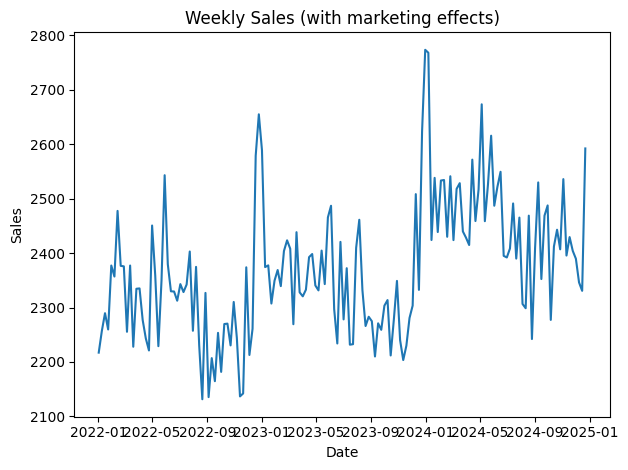

In [5]:
# =========================
# SECTION 3: QUICK PLOT CHECK
# =========================

import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["date"], df["sales"])
plt.title("Weekly Sales (with marketing effects)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()


In [6]:
# ==========================================
# SECTION 4: BUILD MMM FEATURES (MODEL INPUTS)
# ==========================================

# Reuse the same helper functions
def adstock(x, rate=0.5):
    x = np.array(x, dtype=float)
    out = np.zeros_like(x)
    out[0] = x[0]
    for i in range(1, len(x)):
        out[i] = x[i] + rate * out[i-1]
    return out

def saturation(x, alpha=0.001):
    x = np.array(x, dtype=float)
    return 1 - np.exp(-alpha * x)

# These are "our MMM assumptions" (we choose reasonable values)
# In a full MMM project, you'd tune these or estimate them with Bayesian methods.
channel_params = {
    "search":  {"adstock": 0.60, "alpha": 0.0009},
    "social":  {"adstock": 0.50, "alpha": 0.0010},
    "display": {"adstock": 0.40, "alpha": 0.0011},
    "email":   {"adstock": 0.30, "alpha": 0.0025},
}

df_feat = df.copy()

df_feat["x_search"]  = saturation(adstock(df_feat["spend_search"].values,  channel_params["search"]["adstock"]),
                                  channel_params["search"]["alpha"])
df_feat["x_social"]  = saturation(adstock(df_feat["spend_social"].values,  channel_params["social"]["adstock"]),
                                  channel_params["social"]["alpha"])
df_feat["x_display"] = saturation(adstock(df_feat["spend_display"].values, channel_params["display"]["adstock"]),
                                  channel_params["display"]["alpha"])
df_feat["x_email"]   = saturation(adstock(df_feat["spend_email"].values,   channel_params["email"]["adstock"]),
                                  channel_params["email"]["alpha"])

# Model will use these + control variables
feature_cols = ["x_search", "x_social", "x_display", "x_email", "holiday", "trend", "season"]
df_feat[feature_cols + ["sales"]].head()


,x_search,x_social,x_display,x_email,holiday,trend,season,sales
0,0.371767,0.146447,0.198994,0.085366,0.0,0.0,35.000000,2217.112201
1,0.373507,0.230128,0.228682,0.128804,0.0,1.2,43.625898,2257.241399
2,0.394303,0.256376,0.272009,0.154783,0.0,2.4,50.136214,2289.639235
3,0.438293,0.282770,0.233090,0.140438,0.0,3.6,54.566267,2259.706680
4,0.417728,0.386805,0.203929,0.129533,0.0,4.8,57.060120,2377.166278


In [7]:
# ==========================================
# SECTION 5: TRAIN/TEST SPLIT (TIME SERIES)
# ==========================================

from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

split_idx = int(0.80 * len(df_feat))  # 80% train, 20% test

train = df_feat.iloc[:split_idx].copy()
test  = df_feat.iloc[split_idx:].copy()

X_train = train[feature_cols].values
y_train = train["sales"].values

X_test = test[feature_cols].values
y_test = test["sales"].values

print("Train weeks:", len(train), "Test weeks:", len(test))


Train weeks: 124 Test weeks: 32


Train R2: 0.624  | Train MAE: 61.52
Test  R2: 0.009  | Test  MAE: 74.73


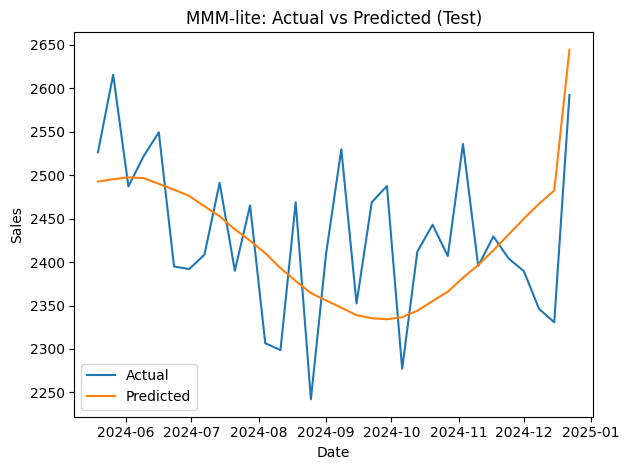

,feature,coef
4,holiday,147.339746
1,x_social,23.845090
0,x_search,20.968037
2,x_display,9.994811
3,x_email,7.455397
5,trend,1.183116
6,season,1.073318


In [8]:
# ==========================================
# SECTION 6: FIT RIDGE MMM + EVALUATE
# ==========================================

model = Ridge(alpha=5.0)  # alpha controls regularization strength
model.fit(X_train, y_train)

pred_train = model.predict(X_train)
pred_test  = model.predict(X_test)

print("Train R2:", round(r2_score(y_train, pred_train), 3), " | Train MAE:", round(mean_absolute_error(y_train, pred_train), 2))
print("Test  R2:", round(r2_score(y_test, pred_test), 3),  " | Test  MAE:", round(mean_absolute_error(y_test, pred_test), 2))

# Plot actual vs predicted (test period)
import matplotlib.pyplot as plt

plt.figure()
plt.plot(test["date"], y_test, label="Actual")
plt.plot(test["date"], pred_test, label="Predicted")
plt.title("MMM-lite: Actual vs Predicted (Test)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

# Show learned coefficients
coef_table = pd.DataFrame({
    "feature": feature_cols,
    "coef": model.coef_
}).sort_values("coef", ascending=False)

coef_table


In [9]:
# ==========================================
# SECTION 7A: COMPUTE CHANNEL CONTRIBUTIONS
# ==========================================

coef_map = dict(zip(feature_cols, model.coef_))
intercept = model.intercept_

contrib = pd.DataFrame(index=df_feat.index)
contrib["date"] = df_feat["date"]

# Channel contributions
contrib["search"]  = coef_map["x_search"]  * df_feat["x_search"]
contrib["social"]  = coef_map["x_social"]  * df_feat["x_social"]
contrib["display"] = coef_map["x_display"] * df_feat["x_display"]
contrib["email"]   = coef_map["x_email"]   * df_feat["x_email"]

# Control contributions
contrib["holiday"] = coef_map["holiday"] * df_feat["holiday"]
contrib["trend"]   = coef_map["trend"]   * df_feat["trend"]
contrib["season"]  = coef_map["season"]  * df_feat["season"]

# Baseline (intercept)
contrib["baseline"] = intercept

# Total reconstructed sales
contrib["sales_reconstructed"] = contrib[
    ["search","social","display","email","holiday","trend","season","baseline"]
].sum(axis=1)

contrib.head()


,date,search,social,display,email,holiday,trend,season,baseline,sales_reconstructed
0,2022-01-02,7.795230,3.492053,1.988910,0.636437,0.0,0.000000,37.566140,2231.556101,2283.034870
1,2022-01-09,7.831705,5.487433,2.285638,0.960283,0.0,1.419739,46.824474,2231.556101,2296.365373
2,2022-01-16,8.267752,6.113319,2.718676,1.153967,0.0,2.839479,53.812115,2231.556101,2306.461409
3,2022-01-23,9.190154,6.742675,2.329695,1.047024,0.0,4.259218,58.566972,2231.556101,2313.691839
4,2022-01-30,8.758930,9.223407,2.038227,0.965722,0.0,5.678957,61.243670,2231.556101,2319.465014


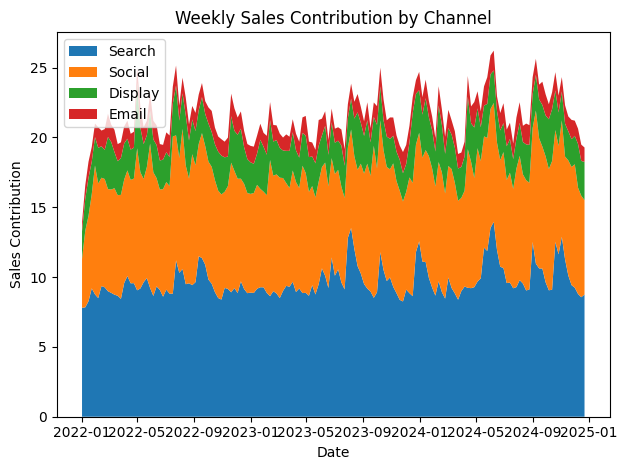

In [10]:
# ==========================================
# SECTION 7B: PLOT CHANNEL CONTRIBUTIONS
# ==========================================

plt.figure()
plt.stackplot(
    contrib["date"],
    contrib["search"],
    contrib["social"],
    contrib["display"],
    contrib["email"],
    labels=["Search","Social","Display","Email"]
)
plt.legend(loc="upper left")
plt.title("Weekly Sales Contribution by Channel")
plt.xlabel("Date")
plt.ylabel("Sales Contribution")
plt.tight_layout()
plt.show()


In [11]:
# ==========================================
# SECTION 7C: TOTAL CONTRIBUTION SUMMARY
# ==========================================

total_contrib = contrib[["search","social","display","email"]].sum()

share_contrib = (total_contrib / total_contrib.sum()) * 100

summary = pd.DataFrame({
    "total_contribution": total_contrib,
    "share_percent": share_contrib
}).sort_values("total_contribution", ascending=False)

summary


,total_contribution,share_percent
search,1508.881341,45.091791
social,1241.530764,37.102218
display,406.432508,12.145932
email,189.399399,5.660059


In [12]:
contrib.to_csv("outputs/weekly_contributions.csv", index=False)
summary.to_csv("outputs/channel_contribution_summary.csv")


In [21]:
# =========================
# SECTION 8 FIXED BLOCK
# =========================

from scipy.optimize import minimize
import numpy as np

# Response function
def channel_response(spend, coef, adstock_rate, alpha):
    ad = adstock(np.array([spend]), adstock_rate)[0]
    sat = saturation(np.array([ad]), alpha)[0]
    return coef * sat

# Coefs from model
coefs = {
    "search":  coef_map["x_search"],
    "social":  coef_map["x_social"],
    "display": coef_map["x_display"],
    "email":   coef_map["x_email"],
}

# IMPORTANT: keys match function args now (adstock_rate, alpha)
params = {
    "search":  {"adstock_rate": channel_params["search"]["adstock"],  "alpha": channel_params["search"]["alpha"]},
    "social":  {"adstock_rate": channel_params["social"]["adstock"],  "alpha": channel_params["social"]["alpha"]},
    "display": {"adstock_rate": channel_params["display"]["adstock"], "alpha": channel_params["display"]["alpha"]},
    "email":   {"adstock_rate": channel_params["email"]["adstock"],   "alpha": channel_params["email"]["alpha"]},
}

def total_sales(spend_vec):
    spend_search, spend_social, spend_display, spend_email = spend_vec
    
    total = 0
    total += channel_response(spend_search,  coefs["search"],  **params["search"])
    total += channel_response(spend_social,  coefs["social"],  **params["social"])
    total += channel_response(spend_display, coefs["display"], **params["display"])
    total += channel_response(spend_email,   coefs["email"],   **params["email"])
    
    return -total  # minimize negative => maximize total

# Budget and constraints
avg_budget = (
    df["spend_search"].mean()
  + df["spend_social"].mean()
  + df["spend_display"].mean()
  + df["spend_email"].mean()
)

bounds = [
    (0.5 * df["spend_search"].mean(),  1.5 * df["spend_search"].mean()),
    (0.5 * df["spend_social"].mean(),  1.5 * df["spend_social"].mean()),
    (0.5 * df["spend_display"].mean(), 1.5 * df["spend_display"].mean()),
    (0.5 * df["spend_email"].mean(),   1.5 * df["spend_email"].mean()),
]

constraint = {"type": "eq", "fun": lambda x: np.sum(x) - avg_budget}

x0 = [
    df["spend_search"].mean(),
    df["spend_social"].mean(),
    df["spend_display"].mean(),
    df["spend_email"].mean(),
]

result = minimize(
    total_sales,
    x0=x0,
    bounds=bounds,
    constraints=[constraint],
    method="SLSQP"
)

result.success, result.message


(True, 'Optimization terminated successfully')

In [22]:
opt_spend = pd.Series(result.x, index=["Search","Social","Display","Email"])
current_spend = pd.Series({
    "Search":  df["spend_search"].mean(),
    "Social":  df["spend_social"].mean(),
    "Display": df["spend_display"].mean(),
    "Email":   df["spend_email"].mean(),
})

comparison = pd.DataFrame({
    "current_spend": current_spend,
    "optimized_spend": opt_spend,
    "change_%": 100 * (opt_spend - current_spend) / current_spend
})

comparison


,current_spend,optimized_spend,change_%
Search,280.004805,248.817029,-11.138300
Social,205.098841,307.648262,50.000000
Display,167.028609,83.514304,-50.000000
Email,50.028249,62.180909,24.291596


In [23]:
comparison.round(2).to_csv("outputs/final_budget_recommendation.csv")


In [26]:
# ==========================================
# SECTION 9A: SIMULATE USER-LEVEL CAUSAL DATA
# ==========================================

import numpy as np
import pandas as pd

np.random.seed(42)

n_users = 20000

uplift_df = pd.DataFrame({
    "user_id": range(n_users),
    "prior_engagement": np.random.beta(2, 5, n_users),      # 0..1
    "price_sensitivity": np.random.beta(3, 3, n_users),     # 0..1
    "is_returning": np.random.binomial(1, 0.4, n_users)     # 0/1
})

# Randomized treatment assignment (simulating exposure)
uplift_df["treated"] = np.random.binomial(1, 0.5, n_users)

# Base conversion probability (without treatment)
base_conv = (
    0.02
    + 0.16 * uplift_df["prior_engagement"]
    + 0.05 * uplift_df["is_returning"]
    - 0.05 * uplift_df["price_sensitivity"]
)

# True heterogeneous treatment effect (uplift varies by user)
true_uplift = (
    0.10 * uplift_df["prior_engagement"]
    + 0.04 * uplift_df["is_returning"]
    - 0.06 * uplift_df["price_sensitivity"]
)

# Observed conversion probability
uplift_df["conversion_prob"] = np.clip(
    base_conv + uplift_df["treated"] * true_uplift,
    0, 1
)

# Observed outcome (converted = 1/0)
uplift_df["converted"] = np.random.binomial(1, uplift_df["conversion_prob"])

uplift_df.head()


,user_id,prior_engagement,price_sensitivity,is_returning,treated,conversion_prob,converted
0,0,0.353677,0.622007,0,0,0.045488,0
1,1,0.248558,0.549611,0,0,0.032289,0
2,2,0.415959,0.485787,0,0,0.062264,0
3,3,0.159968,0.776203,1,0,0.056785,0
4,4,0.550283,0.208682,0,1,0.140119,0


In [27]:
# ==========================================
# SECTION 9B: TRAIN UPLIFT MODELS (TWO-MODEL)
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

features = ["prior_engagement", "price_sensitivity", "is_returning"]

train_df, test_df = train_test_split(uplift_df, test_size=0.25, random_state=42, stratify=uplift_df["treated"])

treated_train = train_df[train_df["treated"] == 1]
control_train = train_df[train_df["treated"] == 0]

model_treated = RandomForestClassifier(max_depth=6, n_estimators=200, random_state=42)
model_control = RandomForestClassifier(max_depth=6, n_estimators=200, random_state=42)

model_treated.fit(treated_train[features], treated_train["converted"])
model_control.fit(control_train[features], control_train["converted"])

# Predict probabilities for test set (counterfactual style)
test_df = test_df.copy()
test_df["p_treated"] = model_treated.predict_proba(test_df[features])[:, 1]
test_df["p_control"] = model_control.predict_proba(test_df[features])[:, 1]
test_df["uplift_pred"] = test_df["p_treated"] - test_df["p_control"]

test_df[["p_treated", "p_control", "uplift_pred"]].head()


,p_treated,p_control,uplift_pred
5656,0.050711,0.066904,-0.016193
14444,0.011181,0.018470,-0.007289
14983,0.170116,0.102539,0.067577
2556,0.272587,0.159501,0.113086
7613,0.157344,0.104513,0.052831


In [28]:
# ==========================================
# SECTION 9C: UPLIFT VALIDATION BY BUCKET
# ==========================================

test_df["uplift_bucket"] = pd.qcut(test_df["uplift_pred"], 5, labels=False)

bucket_rows = []
for b in sorted(test_df["uplift_bucket"].unique()):
    d = test_df[test_df["uplift_bucket"] == b]
    conv_t = d[d["treated"] == 1]["converted"].mean()
    conv_c = d[d["treated"] == 0]["converted"].mean()
    bucket_rows.append({
        "bucket": int(b),
        "treated_conv_rate": conv_t,
        "control_conv_rate": conv_c,
        "observed_uplift": conv_t - conv_c,
        "n_users": len(d)
    })

uplift_bucket_summary = pd.DataFrame(bucket_rows).sort_values("bucket")
uplift_bucket_summary


,bucket,treated_conv_rate,control_conv_rate,observed_uplift,n_users
0,0,0.029350,0.022945,0.006406,1000
1,1,0.028958,0.039419,-0.010462,1000
2,2,0.077731,0.062977,0.014754,1000
3,3,0.109827,0.083160,0.026667,1000
4,4,0.164062,0.084016,0.080046,1000


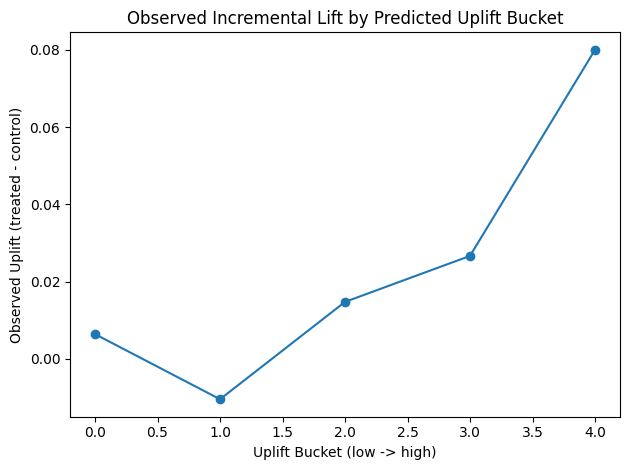

In [29]:
# ==========================================
# SECTION 9D: PLOT OBSERVED UPLIFT BY BUCKET
# ==========================================

import matplotlib.pyplot as plt

plt.figure()
plt.plot(uplift_bucket_summary["bucket"], uplift_bucket_summary["observed_uplift"], marker="o")
plt.title("Observed Incremental Lift by Predicted Uplift Bucket")
plt.xlabel("Uplift Bucket (low -> high)")
plt.ylabel("Observed Uplift (treated - control)")
plt.tight_layout()
plt.show()


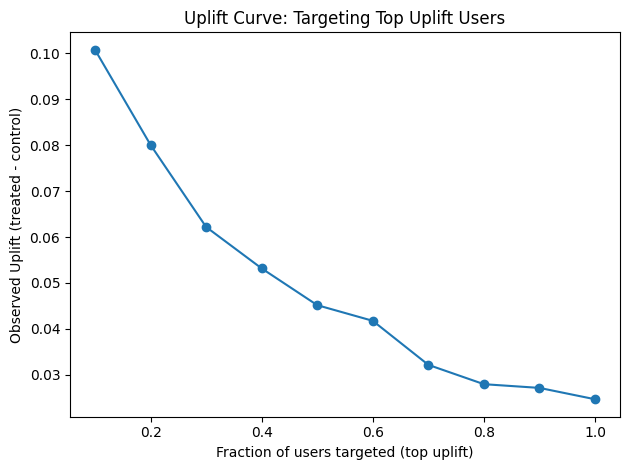

,target_fraction,observed_uplift,n_users
0,0.1,0.100762,500
1,0.2,0.080046,1000
2,0.3,0.062190,1500
3,0.4,0.053169,2000
4,0.5,0.045169,2500
5,0.6,0.041759,3000
6,0.7,0.032174,3500
7,0.8,0.027967,4000
8,0.9,0.027158,4500
9,1.0,0.024687,5000


In [30]:
# ==========================================
# SECTION 9E: UPLIFT CURVE (TARGET TOP X%)
# ==========================================

d = test_df.sort_values("uplift_pred", ascending=False).reset_index(drop=True)

fractions = np.linspace(0.1, 1.0, 10)  # top 10%, 20%, ... 100%
curve = []

for f in fractions:
    k = int(f * len(d))
    top = d.iloc[:k]

    conv_t = top[top["treated"] == 1]["converted"].mean()
    conv_c = top[top["treated"] == 0]["converted"].mean()

    curve.append({
        "target_fraction": f,
        "observed_uplift": conv_t - conv_c,
        "n_users": k
    })

uplift_curve = pd.DataFrame(curve)

plt.figure()
plt.plot(uplift_curve["target_fraction"], uplift_curve["observed_uplift"], marker="o")
plt.title("Uplift Curve: Targeting Top Uplift Users")
plt.xlabel("Fraction of users targeted (top uplift)")
plt.ylabel("Observed Uplift (treated - control)")
plt.tight_layout()
plt.show()

uplift_curve


In [31]:
# ==========================================
# SECTION 9F: EXPORT CAUSAL OUTPUTS
# ==========================================

uplift_bucket_summary.to_csv("outputs/uplift_bucket_summary.csv", index=False)
uplift_curve.to_csv("outputs/uplift_curve.csv", index=False)

print("Saved outputs/uplift_bucket_summary.csv and outputs/uplift_curve.csv ✅")


Saved outputs/uplift_bucket_summary.csv and outputs/uplift_curve.csv ✅
